___

<a href='http://www.pieriandata.com'> <img src='../Pierian_Data_Logo.png' /></a>
___

# Finance Data Project 

In this data project we will focus on exploratory data analysis of stock prices. Keep in mind, this project is just meant to practice your visualization and pandas skills, it is not meant to be a robust financial analysis or be taken as financial advice.
____
** NOTE: This project is extremely challenging because it will introduce a lot of new concepts and have you looking things up on your own (we'll point you in the right direction) to try to solve the tasks issued. Feel free to just go through the solutions lecture notebook and video as a "walkthrough" project if you don't want to have to look things up yourself. You'll still learn a lot that way! **
____
We'll focus on bank stocks and see how they progressed throughout the [financial crisis](https://en.wikipedia.org/wiki/Financial_crisis_of_2007%E2%80%9308) all the way to early 2016.

## Get the Data

In this section we will learn how to use pandas to directly read data from Google finance using pandas!

First we need to start with the proper imports, which we've already laid out for you here.

*Note: [You'll need to install pandas-datareader for this to work!](https://github.com/pydata/pandas-datareader) Pandas datareader allows you to [read stock information directly from the internet](http://pandas.pydata.org/pandas-docs/stable/remote_data.html) Use these links for install guidance (**pip install pandas-datareader**), or just follow along with the video lecture.*

### The Imports

Already filled out for you.

In [2]:
import pandas_datareader.data as wb
import pandas as pd
import numpy as np
import datetime
%matplotlib inline

## Data

We need to get data using pandas datareader. We will get stock information for the following banks:
*  Bank of America
* CitiGroup
* Goldman Sachs
* JPMorgan Chase
* Morgan Stanley
* Wells Fargo

** Figure out how to get the stock data from Jan 1st 2006 to Jan 1st 2016 for each of these banks. Set each bank to be a separate dataframe, with the variable name for that bank being its ticker symbol. This will involve a few steps:**
1. Use datetime to set start and end datetime objects.
2. Figure out the ticker symbol for each bank.
2. Figure out how to use datareader to grab info on the stock.

** Use [this documentation page](https://pandas-datareader.readthedocs.io/en/latest/remote_data.html) for hints and instructions (it should just be a matter of replacing certain values. Use google finance as a source, for example:**
    
    # Bank of America
    BAC = data.DataReader("BAC", 'google', start, end)

### WARNING: MAKE SURE TO CHECK THE LINK ABOVE FOR THE LATEST WORKING API. "google" MAY NOT ALWAYS WORK. 
------------
### We also provide pickle file in the article lecture right before the video lectures.

In [3]:
start = datetime.datetime(2006,1,1)
end = datetime.datetime(2016,1,1)

In [4]:
import yfinance as yf




BAC = yf.download('BAC',start,end)

C = yf.download('C',start,end)

GS = yf.download('GS',start,end)

JPM = yf.download('JPM',start,end)

MS = yf.download('MS',start,end)

WFC  = yf.download('WFC',start,end)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [9]:
BAC.columns = BAC.columns.droplevel(1)
C.columns = C.columns.droplevel(1)
GS.columns = GS.columns.droplevel(1)
JPM.columns = JPM.columns.droplevel(1)
MS.columns = MS.columns.droplevel(1)
WFC.columns = WFC.columns.droplevel(1)


IndexError: Too many levels: Index has only 1 level, not 2

** Create a list of the ticker symbols (as strings) in alphabetical order. Call this list: tickers**

In [12]:
tickers = ['BAC', 'C', 'GS', 'JPM', 'MS', 'WFC']



** Use pd.concat to concatenate the bank dataframes together to a single data frame called bank_stocks. Set the keys argument equal to the tickers list. Also pay attention to what axis you concatenate on.**

In [16]:
bankstock = yf.download(tickers,start,end,group_by='ticker')

bankstock

[*********************100%***********************]  6 of 6 completed


Ticker            WFC                                                   BAC  \
Price            Open       High        Low      Close    Volume       Open   
Date                                                                          
2006-01-03  18.295781  18.512899  18.061294  18.469475  11016400  30.556089   
2006-01-04  18.411573  18.423153  18.159717  18.255249  10870000  30.608182   
2006-01-05  18.237878  18.269722  18.127871  18.234983  10158000  30.334670   
2006-01-06  18.284202  18.397103  18.171301  18.342100   8403800  30.477938   
2006-01-09  18.339197  18.426045  18.269720  18.339197   5619600  30.425843   
...               ...        ...        ...        ...       ...        ...   
2015-12-24  41.449162  41.539645  41.253112  41.336056   4999400  13.911311   
2015-12-28  41.132478  41.305905  40.845945  41.230503   8288800  13.830997   
2015-12-29  41.554742  41.735708  41.464259  41.690468   7894900  13.855093   
2015-12-30  41.675381  41.705543  41.313445  41.388847   8016900  13.814931   
2015-12-31  41.102323  41.434099  40.883656  40.989220  10929800  13.662327   

Ticker                                                 ...        JPM  \
Price            High        Low      Close    Volume  ...       Open   
Date                                                   ...              
2006-01-03  30.725413  30.054638  30.660290  16296700  ...  23.541858   
2006-01-04  30.764480  30.250002  30.334663  17757900  ...  23.712909   
2006-01-05  30.497480  30.165347  30.373743  14970700  ...  23.611565   
2006-01-06  30.549575  30.184880  30.328154  12599800  ...  23.796363   
2006-01-09  30.588652  30.191397  30.347692  15619400  ...  23.772517   
...               ...        ...        ...       ...  ...        ...   
2015-12-24  13.959502  13.830991  13.871152  29369400  ...  50.603414   
2015-12-28  13.839029  13.638230  13.758709  41777500  ...  50.352737   
2015-12-29  13.935413  13.782806  13.879189  45670400  ...  50.770522   
2015-12-30  13.847058  13.686420  13.694450  35066400  ...  50.922424   
2015-12-31  13.710518  13.517752  13.517752  47153000  ...  50.276798   

Ticker                                                          C              \
Price            High        Low      Close    Volume        Open        High   
Date                                                                            
2006-01-03  23.855118  23.228595  23.754637  12838600  315.581890  318.029252   
2006-01-04  23.927506  23.498312  23.617533  13491500  314.680325  316.226029   
2006-01-05  23.730785  23.545993  23.689058   8109400  311.975321  314.165069   
2006-01-06  23.987117  23.575806  23.855974   7966900  314.809114  314.937931   
2006-01-09  24.273242  23.772517  24.243435  16575200  313.005696  313.907354   
...               ...        ...        ...       ...         ...         ...   
2015-12-24  50.808498  50.375536  50.588219   4468200   39.201475   39.567496   
2015-12-28  50.474267  49.912178  50.421097   6610600   39.268714   39.268714   
2015-12-29  51.119935  50.694565  50.945229   9820800   39.410634   39.754247   
2015-12-30  50.930022  50.474267  50.580608   7190700   39.470390   39.545087   
2015-12-31  50.724949  50.132475  50.155262  14654300   38.895214   39.134248   

Ticker                                        
Price              Low       Close    Volume  
Date                                          
2006-01-03  309.849896  317.449615   1537600  
2006-01-04  311.395692  311.588898   1870960  
2006-01-05  311.717707  313.134613   1143160  
2006-01-06  310.429617  313.134613   1370210  
2006-01-09  311.073562  311.653198   1680740  
...                ...         ...       ...  
2015-12-24   39.179066   39.373280   4671200  
2015-12-28   38.813056   39.126789   8761700  
2015-12-29   39.395697   39.574970  10155100  
2015-12-30   39.029672   39.067020   8763300  
2015-12-31   38.656181   38.656181  11281800  

[2517 rows x 30 columns]

** Set the column name levels (this is filled out for you):**

In [18]:
bankstock.columns.names = ['Bank Ticker','Stock Info']

** Check the head of the bank_stocks dataframe.**

In [19]:
bankstock.head()

Bank Ticker        WFC                                                   BAC  \
Stock Info        Open       High        Low      Close    Volume       Open   
Date                                                                           
2006-01-03   18.295781  18.512899  18.061294  18.469475  11016400  30.556089   
2006-01-04   18.411573  18.423153  18.159717  18.255249  10870000  30.608182   
2006-01-05   18.237878  18.269722  18.127871  18.234983  10158000  30.334670   
2006-01-06   18.284202  18.397103  18.171301  18.342100   8403800  30.477938   
2006-01-09   18.339197  18.426045  18.269720  18.339197   5619600  30.425843   

Bank Ticker                                             ...        JPM  \
Stock Info        High        Low      Close    Volume  ...       Open   
Date                                                    ...              
2006-01-03   30.725413  30.054638  30.660290  16296700  ...  23.541858   
2006-01-04   30.764480  30.250002  30.334663  17757900  ...  23.712909   
2006-01-05   30.497480  30.165347  30.373743  14970700  ...  23.611565   
2006-01-06   30.549575  30.184880  30.328154  12599800  ...  23.796363   
2006-01-09   30.588652  30.191397  30.347692  15619400  ...  23.772517   

Bank Ticker                                                      C  \
Stock Info        High        Low      Close    Volume        Open   
Date                                                                 
2006-01-03   23.855118  23.228595  23.754637  12838600  315.581890   
2006-01-04   23.927506  23.498312  23.617533  13491500  314.680325   
2006-01-05   23.730785  23.545993  23.689058   8109400  311.975321   
2006-01-06   23.987117  23.575806  23.855974   7966900  314.809114   
2006-01-09   24.273242  23.772517  24.243435  16575200  313.005696   

Bank Ticker                                               
Stock Info         High         Low       Close   Volume  
Date                                                      
2006-01-03   318.029252  309.849896  317.449615  1537600  
2006-01-04   316.226029  311.395692  311.588898  1870960  
2006-01-05   314.165069  311.717707  313.134613  1143160  
2006-01-06   314.937931  310.429617  313.134613  1370210  
2006-01-09   313.907354  311.073562  311.653198  1680740  

[5 rows x 30 columns]

# EDA

Let's explore the data a bit! Before continuing, I encourage you to check out the documentation on [Multi-Level Indexing](http://pandas.pydata.org/pandas-docs/stable/advanced.html) and [Using .xs](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.xs.html).
Reference the solutions if you can not figure out how to use .xs(), since that will be a major part of this project.

** What is the max Close price for each bank's stock throughout the time period?**

In [33]:
for i in bankstock.columns.levels[0]:
    print(f"{i}  "+f"{bankstock[i]['High'].max()}")



bankstock.xs(key='Close',axis=1,level='Stock Info').max()

BAC  37.25456845526663
C  382.42615079069907
GS  185.31375382697513
JPM  53.24992011500975
MS  50.327962375784736
WFC  43.7265129935749


Bank Ticker
WFC     43.540520
BAC     37.078724
MS      49.414940
GS     183.258820
JPM     52.850235
C      378.467773
dtype: float64

** Create a new empty DataFrame called returns. This dataframe will contain the returns for each bank's stock. returns are typically defined by:**

$$r_t = \frac{p_t - p_{t-1}}{p_{t-1}} = \frac{p_t}{p_{t-1}} - 1$$

In [37]:
returns = pd.DataFrame()

for tick in tickers:
    returns[tick + 'Return'] = bankstock[tick]['Close'].pct_change()

returns

,BACReturn,CReturn,GSReturn,JPMReturn,MSReturn,WFCReturn
Date,,,,,,
2006-01-03,NaN,NaN,NaN,NaN,NaN,NaN
2006-01-04,-0.010620,-0.018462,-0.013813,-0.005772,0.000686,-0.011599
2006-01-05,0.001288,0.004961,-0.000393,0.003028,0.002742,-0.001110
2006-01-06,-0.001501,0.000000,0.014169,0.007046,0.001025,0.005874
2006-01-09,0.000644,-0.004731,0.012030,0.016242,0.010586,-0.000158
...,...,...,...,...,...,...
2015-12-24,-0.004037,0.001520,-0.002624,-0.001948,-0.003681,-0.003997
2015-12-28,-0.008106,-0.006260,-0.004658,-0.003304,-0.009545,-0.002554
2015-12-29,0.008757,0.011455,0.010517,0.010395,0.011812,0.011156


** We can use pandas pct_change() method on the Close column to create a column representing this return value. Create a for loop that goes and for each Bank Stock Ticker creates this returns column and set's it as a column in the returns DataFrame.**

,BAC Return,C Return,GS Return,JPM Return,MS Return,WFC Return
Date,,,,,,
2006-01-03,NaN,NaN,NaN,NaN,NaN,NaN
2006-01-04,-0.010620,-0.018462,-0.013812,-0.014183,0.000686,-0.011599
2006-01-05,0.001288,0.004961,-0.000393,0.003029,0.002742,-0.000951
2006-01-06,-0.001501,0.000000,0.014169,0.007046,0.001025,0.005714
2006-01-09,0.000644,-0.004731,0.012030,0.016242,0.010586,0.000000


** Create a pairplot using seaborn of the returns dataframe. What stock stands out to you? Can you figure out why?**

<Figure size 1200x600 with 0 Axes>

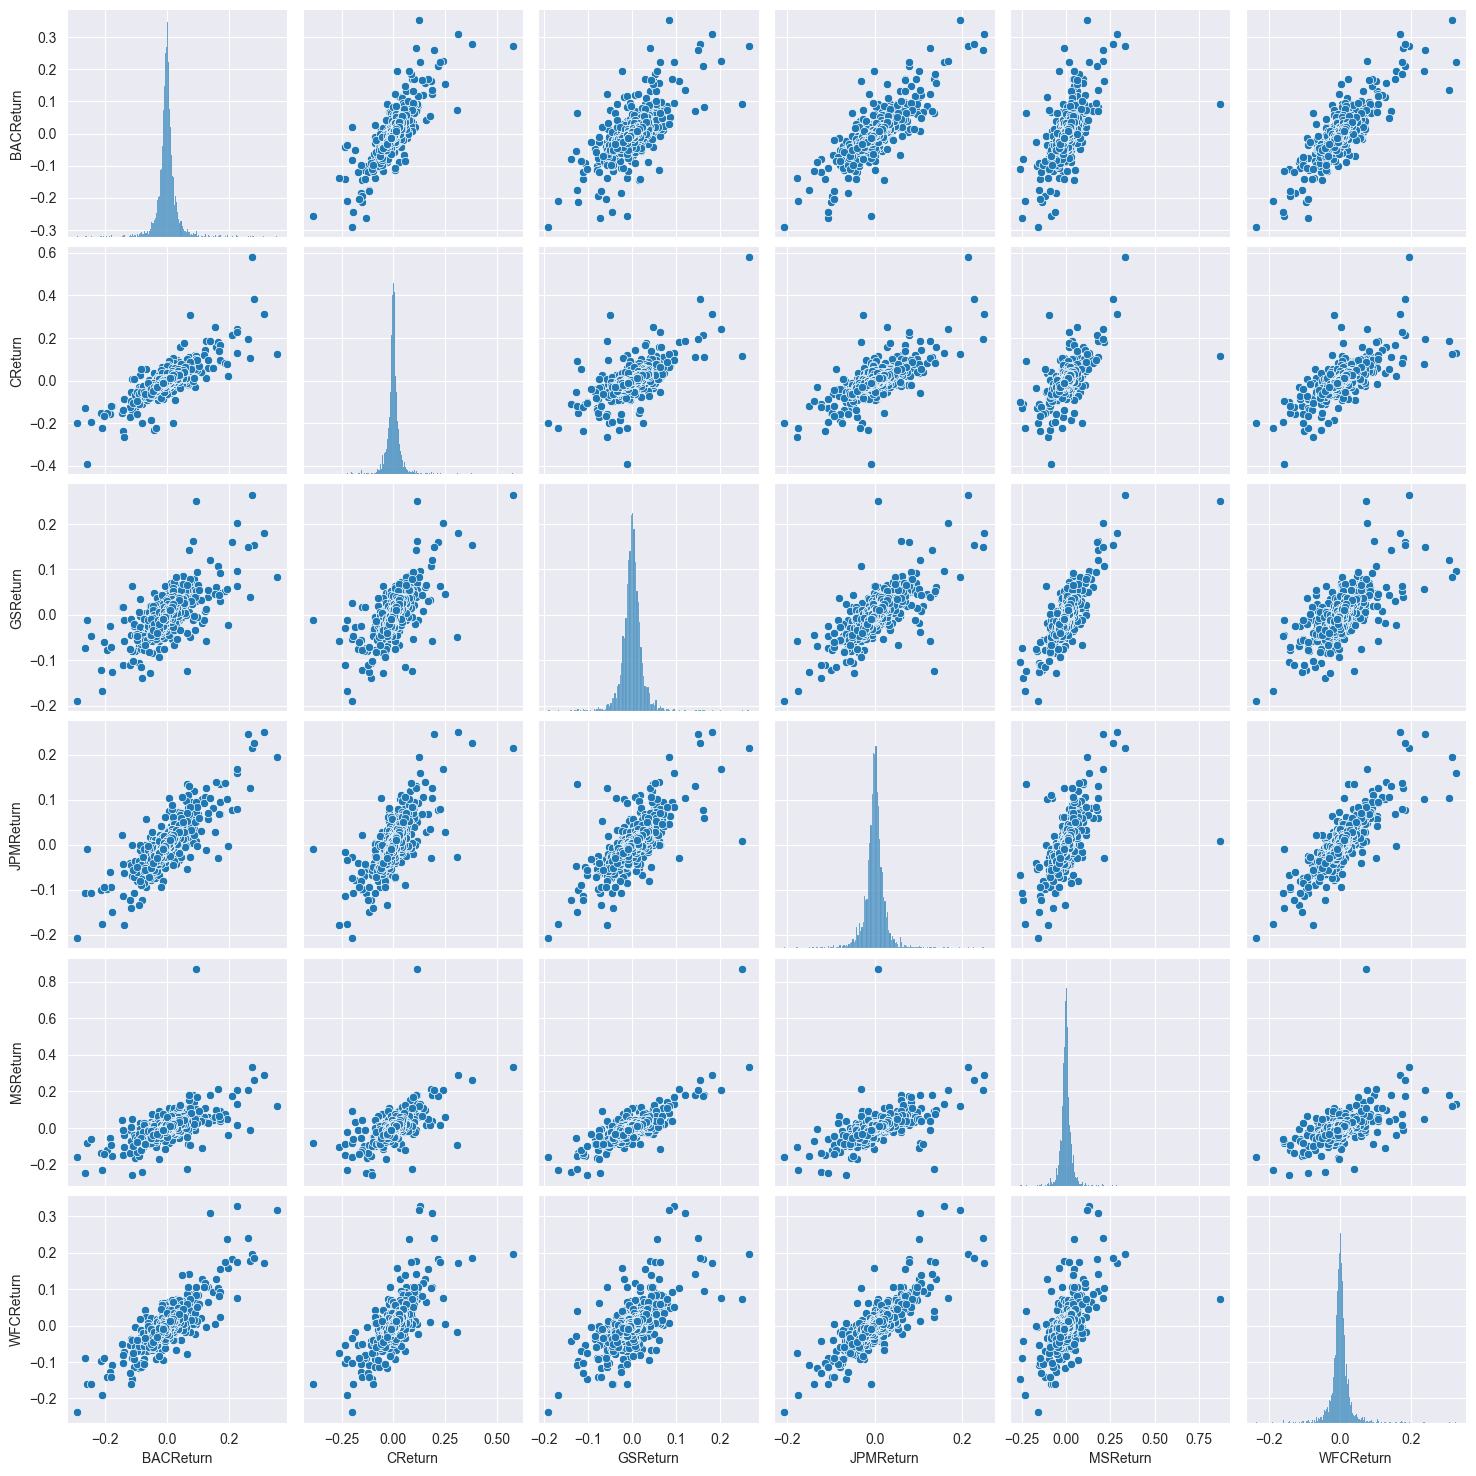

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

plt.figure(figsize=(12,6))

sns.pairplot(returns)

* See solution for details about Citigroup behavior....

** Using this returns DataFrame, figure out on what dates each bank stock had the best and worst single day returns. You should notice that 4 of the banks share the same day for the worst drop, did anything significant happen that day?**

In [55]:
for columns in returns.columns:

    print(f"{columns} {returns.index[returns[columns] == returns[columns].min()][0]}")



returns.idxmin()

BACReturn 2009-01-20 00:00:00
CReturn 2009-02-27 00:00:00
GSReturn 2009-01-20 00:00:00
JPMReturn 2009-01-20 00:00:00
MSReturn 2008-10-09 00:00:00
WFCReturn 2009-01-20 00:00:00


BACReturn   2009-01-20
CReturn     2009-02-27
GSReturn    2009-01-20
JPMReturn   2009-01-20
MSReturn    2008-10-09
WFCReturn   2009-01-20
dtype: datetime64[ns]

** You should have noticed that Citigroup's largest drop and biggest gain were very close to one another, did anythign significant happen in that time frame? **

* See Solution for details

In [56]:
returns.idxmax()

BACReturn   2009-04-09
CReturn     2008-11-24
GSReturn    2008-11-24
JPMReturn   2009-01-21
MSReturn    2008-10-13
WFCReturn   2008-07-16
dtype: datetime64[ns]

** Take a look at the standard deviation of the returns, which stock would you classify as the riskiest over the entire time period? Which would you classify as the riskiest for the year 2015?**

In [57]:
returns.std()


BACReturn    0.036659
CReturn      0.038672
GSReturn     0.025386
JPMReturn    0.027675
MSReturn     0.037717
WFCReturn    0.030195
dtype: float64

In [59]:
returns['2015-01-01':'2015-12-31'].std()

BACReturn    0.016174
CReturn      0.015288
GSReturn     0.014043
JPMReturn    0.014006
MSReturn     0.016287
WFCReturn    0.012552
dtype: float64

** Create a distplot using seaborn of the 2015 returns for Morgan Stanley **

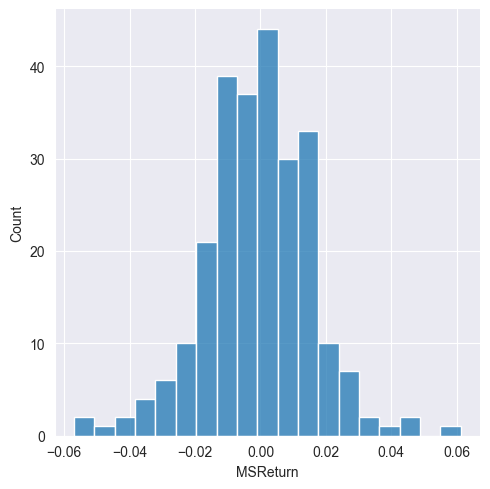

In [60]:
sns.displot(returns['2015-01-01':'2015-12-31']['MSReturn'])

** Create a distplot using seaborn of the 2008 returns for CitiGroup **

<Figure size 1200x600 with 0 Axes>

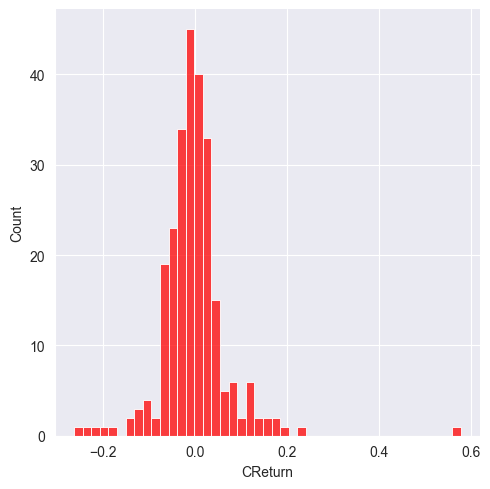

In [63]:
plt.figure(figsize=(12,6))

sns.displot(returns['2008-01-01':'2008-12-31']['CReturn'],color='red')


____
# More Visualization

A lot of this project will focus on visualizations. Feel free to use any of your preferred visualization libraries to try to recreate the described plots below, seaborn, matplotlib, plotly and cufflinks, or just pandas.

### Imports

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

# Optional Plotly Method Imports
import plotly
import cufflinks as cf
cf.go_offline()

** Create a line plot showing Close price for each bank for the entire index of time. (Hint: Try using a for loop, or use [.xs](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.xs.html) to get a cross section of the data.)**

<Axes: xlabel='Date'>

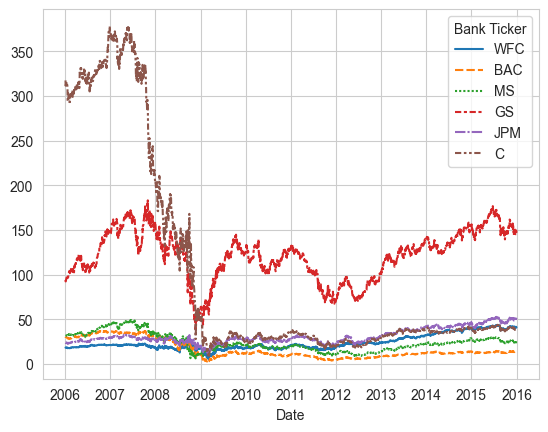

In [66]:
sns.lineplot(bankstock.xs(key='Close',axis=1,level='Stock Info'))

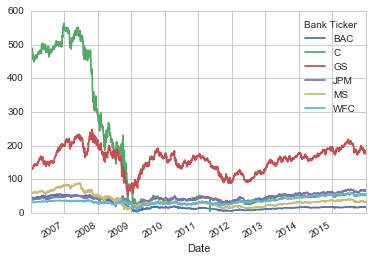

## Moving Averages

Let's analyze the moving averages for these stocks in the year 2008. 

** Plot the rolling 30 day average against the Close Price for Bank Of America's stock for the year 2008**

<Axes: xlabel='Date'>

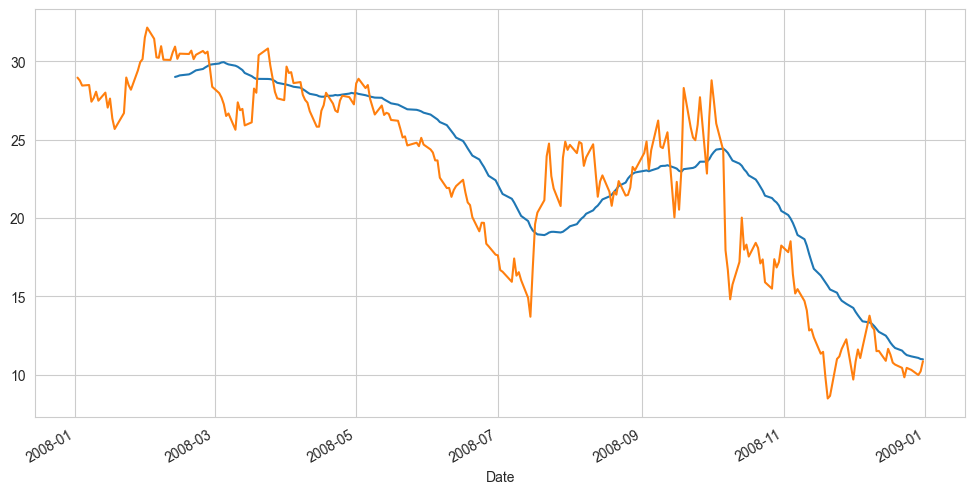

In [73]:
plt.figure(figsize=(12,6))
bankstock['BAC']['Close'].loc['2008-01-01':'2009-01-01'].rolling(window=30).mean().plot(label='30 day average')
bankstock['BAC']['Close'].loc['2008-01-01':'2009-01-01'].plot(label='Close')

** Create a heatmap of the correlation between the stocks Close Price.**

<Axes: xlabel='Bank Ticker', ylabel='Date'>

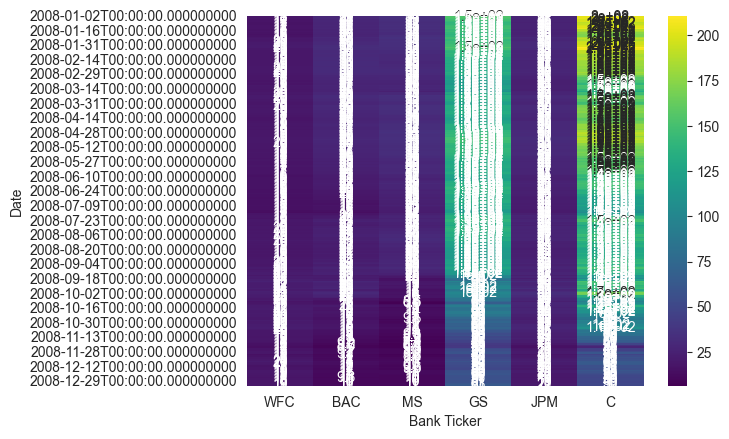

In [75]:
sns.heatmap(bankstock.loc['2008-01-01':'2009-01-01'].xs(key='Close',axis=1,level='Stock Info'),annot=True,cmap='viridis')

** Optional: Use seaborn's clustermap to cluster the correlations together:**

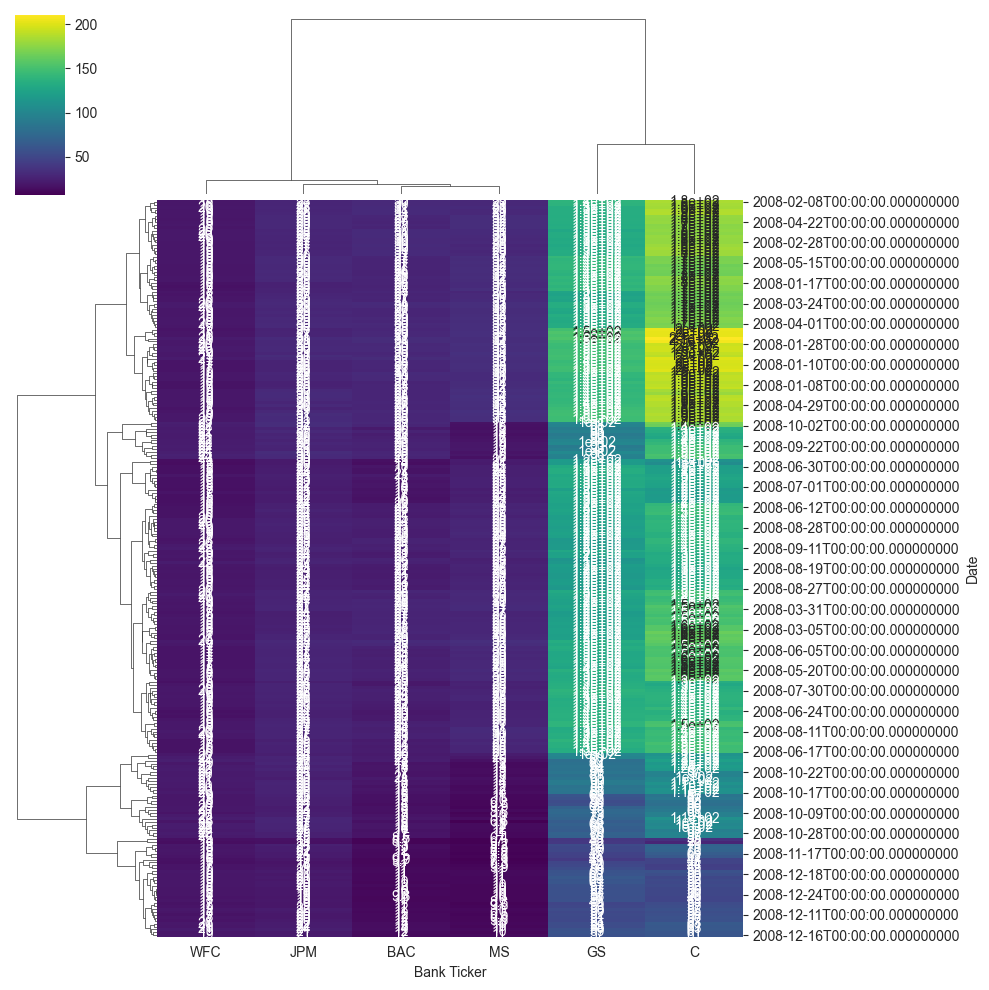

In [76]:
sns.clustermap(bankstock.loc['2008-01-01':'2009-01-01'].xs(key='Close',axis=1,level='Stock Info'),annot=True,cmap='viridis')


# Part 2 (Optional)

In this second part of the project we will rely on the cufflinks library to create some Technical Analysis plots. This part of the project is experimental due to its heavy reliance on the cuffinks project, so feel free to skip it if any functionality is broken in the future.

** Use .iplot(kind='candle) to create a candle plot of Bank of America's stock from Jan 1st 2015 to Jan 1st 2016.**

** Use .ta_plot(study='sma') to create a Simple Moving Averages plot of Morgan Stanley for the year 2015.**

**Use .ta_plot(study='boll') to create a Bollinger Band Plot for Bank of America for the year 2015.**

# Great Job!

Definitely a lot of more specific finance topics here, so don't worry if you didn't understand them all! The only thing you should be concerned with understanding are the basic pandas and visualization oeprations.